# Part 1: Convolutional Neural Networks

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt

# Set device (use GPU if available)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [21]:
# TODO: Determine good hyperparameters
BATCH_SIZE = 64
LEARNING_RATE = 0.001
EPOCHS = 20

# Data Transformations
transform = transforms.Compose([
    # TODO: Define data transformations
    # - Convert images (transforms) to tensors
    # - Normalize pixel values from [0,1] to [-1,1] for better training stability
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

In [22]:
# Load Fashion-MNIST Dataset with the transformations defined above
train_dataset = torchvision.datasets.FashionMNIST(root="./data", train=True, transform=transform, download=True)
test_dataset = torchvision.datasets.FashionMNIST(root="./data", train=False, transform=transform, download=True)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

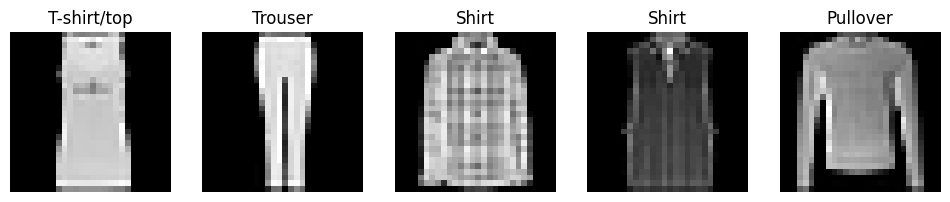

In [23]:
data_iter = iter(train_loader)
images, labels = next(data_iter)

class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

num_images = 5
fig, axes = plt.subplots(1, num_images, figsize=(12, 3))

for i in range(num_images):
    img = images[i].squeeze().numpy()
    label = class_names[labels[i].item()]

    axes[i].imshow(img, cmap="gray")
    axes[i].set_title(label)
    axes[i].axis("off")

plt.show()

In [24]:
# Define CNN Model
class CNN(nn.Module):
    def __init__(self):
        # TODO: Define the layers of the CNN model
        # - The super class is initialized
        # - Use LeNet or AlexNet as an example for designing the layers
        # - Use conv2d for convolutional layers
        super().__init__()
        # num of filters is 6 and size of the kernel is 5
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=6, kernel_size=5) # output 28*28*6
        self.pool1 = nn.MaxPool2d(2, 2) # output 14*14*6

        self.conv2 = nn.Conv2d(in_channels=6, out_channels=16, kernel_size=5) # output 10*10*16
        self.pool2 = nn.MaxPool2d(2, 2) # output 5*5*16

        self.fc1 = nn.Linear(16*4*4, 120)
        self.fc2 = nn.Linear(120, 10) # output 10
    
        self.relu = nn.ReLU()


    def forward(self, x):
        # TODO: Implement the forward pass
        x = self.pool1(self.relu((self.conv1(x))))
        x = self.pool2(self.relu((self.conv2(x))))
        x = torch.flatten(x, 1)
        x = self.fc1(x)
        x = self.fc2(x)
        return x

# Initialize Model
model = CNN().to(device)

# TODO: Define a good Loss function and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

In [25]:
# Training Loop
print("Training model...")
for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        # TODO: Implement the training step
        # - Reset the optimizer's gradients to avoid accumulation
        # - Perform a forward pass to get model predictions
        # - Compute the loss using the criterion
        # - Backpropagate the loss to compute gradients
        # - Update model parameters using the optimizer
        # - Accumulate the loss for tracking the epoch's loss
        optimizer.zero_grad()
        pred = model.forward(images)
        loss = criterion(pred, labels)
        loss.backward()

        optimizer.step()
        epoch_loss += loss.item()

    print(f"Epoch {epoch+1}/{EPOCHS}, Loss: {epoch_loss/len(train_loader):.4f}")

Training model...
Epoch 1/20, Loss: 0.5645
Epoch 2/20, Loss: 0.3918
Epoch 3/20, Loss: 0.3528
Epoch 4/20, Loss: 0.3301
Epoch 5/20, Loss: 0.3143
Epoch 6/20, Loss: 0.3031
Epoch 7/20, Loss: 0.2920
Epoch 8/20, Loss: 0.2833
Epoch 9/20, Loss: 0.2758
Epoch 10/20, Loss: 0.2694
Epoch 11/20, Loss: 0.2653
Epoch 12/20, Loss: 0.2593
Epoch 13/20, Loss: 0.2571
Epoch 14/20, Loss: 0.2548
Epoch 15/20, Loss: 0.2508
Epoch 16/20, Loss: 0.2467
Epoch 17/20, Loss: 0.2454
Epoch 18/20, Loss: 0.2425
Epoch 19/20, Loss: 0.2400
Epoch 20/20, Loss: 0.2388


In [26]:
# Run evaluation
model.eval()
correct, total = 0, 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = correct / total
print(f"Test Accuracy: {accuracy:.4f}")

Test Accuracy: 0.8871


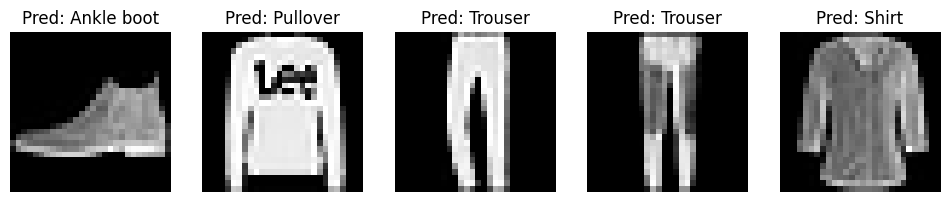

In [27]:
# Visualizing predicted results
data_iter = iter(test_loader)
images, labels = next(data_iter)

images = images.to(device)

model.eval()
with torch.no_grad():
    outputs = model(images)
    _, predicted = torch.max(outputs, 1)

class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

num_images = 5
fig, axes = plt.subplots(1, num_images, figsize=(12, 3))

for i in range(num_images):
    img = images[i].cpu().squeeze().numpy()
    predicted_label = class_names[predicted[i].item()]
    axes[i].imshow(img, cmap="gray")
    axes[i].set_title(f"Pred: {predicted_label}")
    axes[i].axis("off")

plt.show()

# Part 2: Recurrent Neural Networks

In [3]:
# necessary imports
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
from torch.utils.data import Dataset, DataLoader
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score
from collections import Counter
from datasets import load_dataset
import numpy as np
import re

# Set device (use GPU if available)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

c:\Users\Khongor\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cpu


In [9]:
# Load IMDb dataset
print("Loading IMDb dataset...")
dataset = load_dataset("imdb")

# Extract train and test splits
X_train = dataset["train"]["text"]
y_train = [1 if label == 1 else 0 for label in dataset["train"]["label"]]
X_test = dataset["test"]["text"]
y_test = [1 if label == 1 else 0 for label in dataset["test"]["label"]]

# Note: X contains the text data, y contains the labels (0 for negative sentiment, 1 for positive sentiment)

print(f"Loaded {len(X_train)} training samples and {len(X_test)} test samples.")

Loading IMDb dataset...
Loaded 25000 training samples and 25000 test samples.


In [10]:
print(X_train[0])
print(y_train[0])

I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attentions to making some sort of documentary on what the average Swede thought about certain political issues such as the Vietnam War and race issues in the United States. In between asking politicians and ordinary denizens of Stockholm about their opinions on politics, she has sex with her drama teacher, classmates, and married men.<br /><br />What kills me about I AM CURIOUS-YELLOW is that 40 years ago, this was considered pornographic. Really, the sex and nudity scenes are few and far between, eve

In [11]:
MAX_VOCAB_SIZE = 10000  # Number of words in vocabulary
MAX_SEQUENCE_LENGTH = 500  # Max words per review
EMBEDDING_DIM = 100  # Word embedding size

# TODO: Select good hyperparameters
HIDDEN_DIM = 64  # RNN hidden state size
BATCH_SIZE = 32  # Number of samples in each minibatch
EPOCHS = 20  # Number of times to go through the training data
LEARNING_RATE = 0.001  # Learning rate for the optimizer

In [ ]:
# Tokenization (Basic Word Indexing)
# TODO: Implement the preprocess_text function
# - Convert text to lowercase
# - Remove punctuation using regex
# - Split text into individual words (tokenization)
# - Return a list of words
def preprocess_text(text):
    text_lower_case = text.lower()
    filtered = re.sub(r"[^\w\s]", "", text_lower_case)
    split = filtered.split(" ")
    return split

# Build Vocabulary
word_counter = Counter()
for review in X_train:
    word_counter.update(preprocess_text(review))

vocab = ["<PAD>", "<UNK>"] + [word for word, _ in word_counter.most_common(MAX_VOCAB_SIZE - 2)]
word_to_idx = {word: idx for idx, word in enumerate(vocab)}

# Convert text to numerical sequences
def text_to_sequence(text, word_to_idx, max_length):
    words = preprocess_text(text)
    sequence = [word_to_idx.get(word, 1) for word in words]  # 1 is "<UNK>"
    if len(sequence) < max_length:
        sequence += [0] * (max_length - len(sequence))  # Padding
    return sequence[:max_length]

In [29]:
X_train_seq = [text_to_sequence(review, word_to_idx, MAX_SEQUENCE_LENGTH) for review in X_train]
X_test_seq = [text_to_sequence(review, word_to_idx, MAX_SEQUENCE_LENGTH) for review in X_test]

# TODO: Convert data to PyTorch tensors
# - Convert X_train_seq, y_train, X_test_seq, y_test to PyTorch tensors
# - Use torch.tensor() with the correct dtype (long for X and float32 for y)
X_train_tensor = torch.tensor(X_train_seq, dtype=torch.long)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_seq, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)


# Create PyTorch Dataset & DataLoader
class IMDBDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = IMDBDataset(X_train_tensor, y_train_tensor)
test_dataset = IMDBDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

In [ ]:
# Define RNN Model
class SentimentRNN(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim):
        # TODO: Define the layers of the RNN model
        # - Embedding layer to convert word indices to dense vectors
        # - RNN layer (LSTM/RNN) to process sequential data
        # - Fully connected (linear) layer to map hidden state to output
        super().__init__()

        # creating an embedding layer
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        
        # RNN layer 

        # try removing the batch_first
        self.rnn = nn.LSTM(embedding_dim, hidden_dim, num_layers=1, batch_first=True) 

        # linear layer
        self.h2o = nn.Linear(hidden_dim, 1)


    def forward(self, x):
        # TODO: Implement the forward pass
        embedding = self.embedding(x)
        rnn_out, (hidden, cells) = self.rnn(embedding) # rnn_out: every hidden state
        output = self.h2o(hidden[-1]) # hidden: final hidden state

        return output

# Initialize Model
model = SentimentRNN(len(vocab), EMBEDDING_DIM, HIDDEN_DIM).to(device)

# TODO: Define a good Loss function and Optimizer
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

In [ ]:
# Training Loop
# NOTE: As per my testing, the training can take anywhere from 15-22 minutes on CPU and 2-3 minutes on GPU. Your results may vary and might take longer or shorter.

print("Training model.")

for epoch in range(EPOCHS):
    # setting the model to train mode
    model.train()
    epoch_loss = 0

    # iterating over the training data in batches
    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)

        # TODO: Implement the training step
        # - Reset the optimizer's gradients
        # - Forward pass: compute model predictions
        # - Compute the loss using the criterion
        # - Backpropagate the loss
        # - Update model parameters using the optimizer
        # - Accumulate the loss for tracking the epoch's loss
        # I had to unsqueeze it or else the dimensions were not matching 
        batch_y = batch_y.float().unsqueeze(1)
        optimizer.zero_grad()
        pred = model.forward(batch_X)
        loss = criterion(pred, batch_y)
        loss.backward()

        optimizer.step()
        epoch_loss += loss.item()

    print(f"Epoch {epoch+1}/{EPOCHS}, Loss: {epoch_loss/len(train_loader):.4f}")

Training model.
Epoch 1/20, Loss: 0.6937
Epoch 2/20, Loss: 0.6900
Epoch 3/20, Loss: 0.6802
Epoch 4/20, Loss: 0.6617
Epoch 5/20, Loss: 0.6478
Epoch 6/20, Loss: 0.5981
Epoch 7/20, Loss: 0.4566
Epoch 8/20, Loss: 0.3544
Epoch 9/20, Loss: 0.2763
Epoch 10/20, Loss: 0.2174
Epoch 11/20, Loss: 0.1764
Epoch 12/20, Loss: 0.1431
Epoch 13/20, Loss: 0.1249
Epoch 14/20, Loss: 0.0973
Epoch 15/20, Loss: 0.0912
Epoch 16/20, Loss: 0.0824
Epoch 17/20, Loss: 0.0754
Epoch 18/20, Loss: 0.0678
Epoch 19/20, Loss: 0.0588
Epoch 20/20, Loss: 0.0638


In [43]:
# Evaluation
model.eval()
y_true, y_pred = [], []
with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        outputs = model(batch_X)
        predictions = (outputs > 0.5).float()

        y_true.extend(batch_y.cpu().numpy())
        y_pred.extend(predictions.cpu().numpy())

# Compute Metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)

# Goal: Achieve at least 80% accuracy
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")

Test Accuracy: 0.8456
Precision: 0.8681
Recall: 0.8150


# Part 3: Long Short-Term Memory (LSTM)

DOWNLOADING DATA

In [34]:
# Load AG News dataset
print("Loading AG News dataset...")
dataset = load_dataset("ag_news")

# TODO: Extract train and test splits
# - Process the data
# - Define LSTM model
# - Train the model

# Extract train and test splits
X_train = dataset["train"]["text"]
y_train = dataset["train"]["label"]
X_test = dataset["test"]["text"]
y_test = dataset["test"]["label"]

print(f"Loaded {len(X_train)} training samples and {len(X_test)} test samples.")



Loading AG News dataset...
Loaded 120000 training samples and 7600 test samples.


In [35]:
print(X_train[123])
print(y_train[123])

Appeal Rejected in Trout Restoration Plan (AP) AP - The U.S. Forest Service on Wednesday rejected environmentalists' appeal of a plan to poison a stream south of Lake Tahoe to aid what wildlife officials call "the rarest trout in America."
3


TOKENIZE THE TEXT

In [71]:
MAX_VOCAB_SIZE = 20000  # Number of words in vocabulary
MAX_SEQUENCE_LENGTH = 200  # Max words per review
EMBEDDING_DIM = 100  # Word embedding size

# TODO: Select good hyperparameters
HIDDEN_DIM = 200  # RNN hidden state size
BATCH_SIZE = 30  # Number of samples in each minibatch
EPOCHS = 10  # Number of times to go through the training data
LEARNING_RATE = 0.001  # Learning rate for the optimizer

# Tokenization (Basic Word Indexing)
# TODO: Implement the preprocess_text function
# - Convert text to lowercase
# - Remove punctuation using regex
# - Split text into individual words (tokenization)
# - Return a list of words
def preprocess_text(text):
    text_lower_case = text.lower()
    filtered = re.sub(r"[^\w\s]", "", text_lower_case)
    split = filtered.split(" ")
    return split

# Build Vocabulary
word_counter = Counter()
for text in X_train:
    word_counter.update(preprocess_text(text))

vocab = ["<PAD>", "<UNK>"] + [word for word, _ in word_counter.most_common(MAX_VOCAB_SIZE - 2)]
word_to_idx = {word: idx for idx, word in enumerate(vocab)}

# Convert text to numerical sequences
def text_to_sequence(text, word_to_idx, max_length):
    words = preprocess_text(text)
    sequence = [word_to_idx.get(word, 1) for word in words]  # 1 is "<UNK>"
    if len(sequence) < max_length:
        sequence += [0] * (max_length - len(sequence))  # Padding
    return sequence[:max_length]

X_train_seq = [text_to_sequence(text, word_to_idx, MAX_SEQUENCE_LENGTH) for text in X_train]
X_test_seq = [text_to_sequence(text, word_to_idx, MAX_SEQUENCE_LENGTH) for text in X_test]



PREPARE THE DATA

In [47]:
# TODO: Convert data to PyTorch tensors
# - Convert X_train_seq, y_train, X_test_seq, y_test to PyTorch tensors
# - Use torch.tensor() with the correct dtype (long for X and float32 for y)
X_train_tensor = torch.tensor(X_train_seq, dtype=torch.long)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_test_tensor = torch.tensor(X_test_seq, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)


# Create PyTorch Dataset & DataLoader
class AGNews(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = AGNews(X_train_tensor, y_train_tensor)
test_dataset = AGNews(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

DEFINE LSTM MODEL

In [ ]:
# Define LSTM Model
class LSTM(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim):
        # TODO: Define the layers of the LSTM model
        # - Embedding layer to convert word indices to dense vectors
        # - RNN layer (LSTM/RNN) to process sequential data
        # - Fully connected (linear) layer to map hidden state to output
        super().__init__()

        # creating an embedding layer
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        
        # RNN layer 

        # try removing the batch_first
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, num_layers=1, batch_first=True) 

        # linear layer
        self.h2o = nn.Linear(hidden_dim, 4)

    def forward(self, x):
        # TODO: Implement the forward pass
        embedding = self.embedding(x)
        rnn_out, (hidden, cells) = self.lstm(embedding) # rnn_out: every hidden state
        output = self.h2o(hidden[-1]) # hidden: final hidden state

        return output

# Initialize Model
model = LSTM(len(vocab), EMBEDDING_DIM, HIDDEN_DIM).to(device)

# TODO: Define a good Loss function and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

TRAINING THE MODEL

In [72]:
# Training Loop
# NOTE: As per my testing, the training can take anywhere from 15-22 minutes on CPU and 2-3 minutes on GPU. Your results may vary and might take longer or shorter.

print("Training model.")

for epoch in range(EPOCHS):
    # setting the model to train mode
    model.train()
    epoch_loss = 0

    # iterating over the training data in batches
    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)


        # TODO: Implement the training step
        # - Reset the optimizer's gradients
        # - Forward pass: compute model predictions
        # - Compute the loss using the criterion
        # - Backpropagate the loss
        # - Update model parameters using the optimizer
        # - Accumulate the loss for tracking the epoch's loss

        optimizer.zero_grad()
        pred = model.forward(batch_X)
        loss = criterion(pred, batch_y)
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()

    print(f"Epoch {epoch+1}/{EPOCHS}, Loss: {epoch_loss/len(train_loader):.4f}")

Training model.
Epoch 1/10, Loss: 0.0153
Epoch 2/10, Loss: 0.0130
Epoch 3/10, Loss: 0.0140
Epoch 4/10, Loss: 0.0127
Epoch 5/10, Loss: 0.0114
Epoch 6/10, Loss: 0.0109
Epoch 7/10, Loss: 0.0105
Epoch 8/10, Loss: 0.0103
Epoch 9/10, Loss: 0.0104
Epoch 10/10, Loss: 0.0093


EVALUATING THE MODEL

In [65]:
# Evaluation
model.eval()
y_true, y_pred = [], []
with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        output = model(batch_X)

        predictions = output.argmax(1)

        y_true.extend(batch_y.cpu().numpy())
        y_pred.extend(predictions.cpu().numpy())

# Compute Metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average="micro")
recall = recall_score(y_true, y_pred, average="micro")

# Goal: Achieve at least 80% accuracy
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")

Test Accuracy: 0.9009
Precision: 0.9009
Recall: 0.9009


# Part 4: Grid Search of Hyperparameters

In this assignment, you will use the grid search approach to find the best hyperparameters for the LSTM model on AG News from the above assignment.

In [ ]:
# TODO: Define a hyperparameter grid

# NOTE: I had to set the epochs to very low numbers because my cpu was way too slow to compute all of the parameters :(
param_grid = {
    'hidden_dim': [16, 32],
    'batch_size': [10, 20],
    'epochs': [2, 4],
    'learning_rate': [0.001, 0.005]
}

# TODO: Create a validation dataset (split from the training set)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=42)

# Build Vocabulary
word_counter = Counter()
for text in X_train:
    word_counter.update(preprocess_text(text))

vocab = ["<PAD>", "<UNK>"] + [word for word, _ in word_counter.most_common(MAX_VOCAB_SIZE - 2)]
word_to_idx = {word: idx for idx, word in enumerate(vocab)}

X_train_seq = [text_to_sequence(text, word_to_idx, MAX_SEQUENCE_LENGTH) for text in X_train]
X_val_seq    = [text_to_sequence(text, word_to_idx, MAX_SEQUENCE_LENGTH) for text in X_val]


X_train_tensor = torch.tensor(X_train_seq, dtype=torch.long)
y_train_tensor  = torch.tensor(y_train, dtype=torch.long)
X_val_tensor    = torch.tensor(X_val_seq, dtype=torch.long)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)

train_dataset = AGNews(X_train_tensor, y_train_tensor)
test_dataset = AGNews(X_val_tensor, y_val_tensor)





In [80]:
best_accuracy = 0
best_hidden = None
best_batch_size = None
best_epochs = None
best_learning_rate = None

# TODO: Train and evaluate the model by searching hyperparameters within the grid, and record the best scores and the corresponding hyperparameters
for hidden_dim in param_grid['hidden_dim']:
    for batch_size in param_grid['batch_size']:
        for epochs in param_grid['epochs']:
            for learning_rate in param_grid['learning_rate']:
             
                model = LSTM(len(vocab), EMBEDDING_DIM, hidden_dim).to(device)
                criterion = nn.CrossEntropyLoss()
                optimizer = optim.Adam(model.parameters(), lr=learning_rate)
                train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
                test_loader = DataLoader(test_dataset, batch_size=batch_size)

                # Training Loop
                # NOTE: As per my testing, the training can take anywhere from 15-22 minutes on CPU and 2-3 minutes on GPU. Your results may vary and might take longer or shorter.

                print("Training model.")

                for epoch in range(epochs):
                    # setting the model to train mode
                    model.train()
                    epoch_loss = 0

                    # iterating over the training data in batches
                    for batch_X, batch_y in train_loader:
                        batch_X, batch_y = batch_X.to(device), batch_y.to(device)


                        # TODO: Implement the training step
                        # - Reset the optimizer's gradients
                        # - Forward pass: compute model predictions
                        # - Compute the loss using the criterion
                        # - Backpropagate the loss
                        # - Update model parameters using the optimizer
                        # - Accumulate the loss for tracking the epoch's loss

                        optimizer.zero_grad()
                        pred = model.forward(batch_X)
                        loss = criterion(pred, batch_y)
                        loss.backward()
                        optimizer.step()
                        
                        epoch_loss += loss.item()

                    print(f"Epoch {epoch+1}/{epochs}, Loss: {epoch_loss/len(train_loader):.4f}")

                # Evaluation
                model.eval()
                y_true, y_pred = [], []
                with torch.no_grad():
                    for batch_X, batch_y in test_loader:
                        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
                        output = model(batch_X)

                        predictions = output.argmax(1)

                        y_true.extend(batch_y.cpu().numpy())
                        y_pred.extend(predictions.cpu().numpy())

                # Compute Metrics
                accuracy = accuracy_score(y_true, y_pred)
                precision = precision_score(y_true, y_pred, average="micro")
                recall = recall_score(y_true, y_pred, average="micro")

                # Goal: Achieve at least 80% accuracy
                print(f"Test Accuracy: {accuracy:.4f}")
                
                if accuracy > best_accuracy:
                    best_accuracy = accuracy
                    best_hidden = hidden_dim
                    best_batch_size = batch_size
                    best_epochs = epochs
                    best_learning_rate = learning_rate

print(f"best_accuracy: {best_accuracy}, best_hidden: {best_hidden}, best_batch_size: {best_batch_size}, best_epochs: {best_epochs}, best_learning_rate: {best_learning_rate}")
                    

Training model.
Epoch 1/2, Loss: 1.3870
Epoch 2/2, Loss: 1.3865
Test Accuracy: 0.2434
Training model.
Epoch 1/2, Loss: 1.3876
Epoch 2/2, Loss: 1.3872
Test Accuracy: 0.2464
Training model.
Epoch 1/4, Loss: 1.3874
Epoch 2/4, Loss: 1.3868
Epoch 3/4, Loss: 1.3869
Epoch 4/4, Loss: 1.3867
Test Accuracy: 0.2434
Training model.
Epoch 1/4, Loss: 1.3874
Epoch 2/4, Loss: 1.3871
Epoch 3/4, Loss: 1.3869
Epoch 4/4, Loss: 1.3869
Test Accuracy: 0.2464
Training model.
Epoch 1/2, Loss: 1.3871
Epoch 2/2, Loss: 1.3867
Test Accuracy: 0.2434
Training model.
Epoch 1/2, Loss: 1.3876
Epoch 2/2, Loss: 1.3869
Test Accuracy: 0.2464
Training model.
Epoch 1/4, Loss: 1.3872
Epoch 2/4, Loss: 1.3865
Epoch 3/4, Loss: 1.3866
Epoch 4/4, Loss: 1.3867
Test Accuracy: 0.2434
Training model.
Epoch 1/4, Loss: 1.3872
Epoch 2/4, Loss: 1.3867
Epoch 3/4, Loss: 1.3867
Epoch 4/4, Loss: 1.3868
Test Accuracy: 0.2434
Training model.
Epoch 1/2, Loss: 1.3869
Epoch 2/2, Loss: 1.3867
Test Accuracy: 0.2625
Training model.
Epoch 1/2, Loss: 1

In [ ]:
# TODO: Train the model using the parameter values which achieved the highest scores
# training using the best parameters


model = LSTM(len(vocab), EMBEDDING_DIM, best_hidden).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=best_learning_rate)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=best_batch_size)

# Training Loop
# NOTE: As per my testing, the training can take anywhere from 15-22 minutes on CPU and 2-3 minutes on GPU. Your results may vary and might take longer or shorter.

print("Training model.")

for epoch in range(best_epochs):
    # setting the model to train mode
    model.train()
    epoch_loss = 0

    # iterating over the training data in batches
    for batch_X, batch_y in test_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)


        # TODO: Implement the training step
        # - Reset the optimizer's gradients
        # - Forward pass: compute model predictions
        # - Compute the loss using the criterion
        # - Backpropagate the loss
        # - Update model parameters using the optimizer
        # - Accumulate the loss for tracking the epoch's loss

        optimizer.zero_grad()
        pred = model.forward(batch_X)
        loss = criterion(pred, batch_y)
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()

    print(f"Epoch {epoch+1}/{epochs}, Loss: {epoch_loss/len(train_loader):.4f}")

In [ ]:
# TODO: Visualize the grid for two hyperparameters using a heatmap
...